In [1]:
!pip install numpy
!pip install pandas
!pip install seaborn
!pip install matplotlib



In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("E:/Machine Learning/End to end project/mlprojects/notebook/data/stud.csv")

# Top 5 Records

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Shape of the dataset

In [5]:
df.shape

(1000, 8)

## Check Missing Values

In [6]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

## Check Duplicates

In [7]:
df.duplicated().sum()

0

## Check Datatypes

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


## Checking the number of unique values of each column

In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

## Check statastic for dataset

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Exploring Data

In [11]:
print("Categories in gender :",df['gender'].unique())
print("Categories in race_ethnicity :",df['race_ethnicity'].unique())
print("Categories in parental_level_of_education :",df['parental_level_of_education'].unique())
print("Categories in lunch :",df['lunch'].unique())
print("Categories in test_preparation_course :",df['test_preparation_course'].unique())



Categories in gender : ['female' 'male']
Categories in race_ethnicity : ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in parental_level_of_education : ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in lunch : ['standard' 'free/reduced']
Categories in test_preparation_course : ['none' 'completed']


In [12]:
numrical_features = [feature for feature in df.columns if  df[feature].dtype != 'object']
categorical_feature = [feature for feature in df.columns if df[feature].dtype == 'object']

print(f'We have {len(numrical_features)} numrical feature : {numrical_features}')
print(f'We have {len(categorical_feature)} numrical feature : {categorical_feature}')

We have 3 numrical feature : ['math_score', 'reading_score', 'writing_score']
We have 5 numrical feature : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


## Adding Columns for Total Score and Average

In [13]:
df['Total Score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['Average Score'] = df['Total Score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total Score,Average Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [14]:
reading_full = df[df['reading_score']== 100]['Average Score'].count()
writing_score = df[df['writing_score'] == 100]['Average Score'].count()
math_full = df[df['math_score']==100]['Average Score'].count()

print("Full Marks in Reading = ",reading_full)
print("Full Marks in Writing = ",writing_score)
print("Full Marks in Math = ",math_full)

Full Marks in Reading =  17
Full Marks in Writing =  14
Full Marks in Math =  7


In [15]:
reading_less_20 = df[df['reading_score'] <= 20]['Average Score'].count()
writing_less_20 = df[df['writing_score'] <= 20]['Average Score'].count()
math_less_20 = df[df['math_score'] <=20]['Average Score'].count()

print("less than 20 Marks in Reading = ",reading_less_20)
print("less than 20 in Writing = ",writing_less_20)
print("less than 20 in Math = ",math_less_20)

less than 20 Marks in Reading =  1
less than 20 in Writing =  3
less than 20 in Math =  4


## Visuvalization

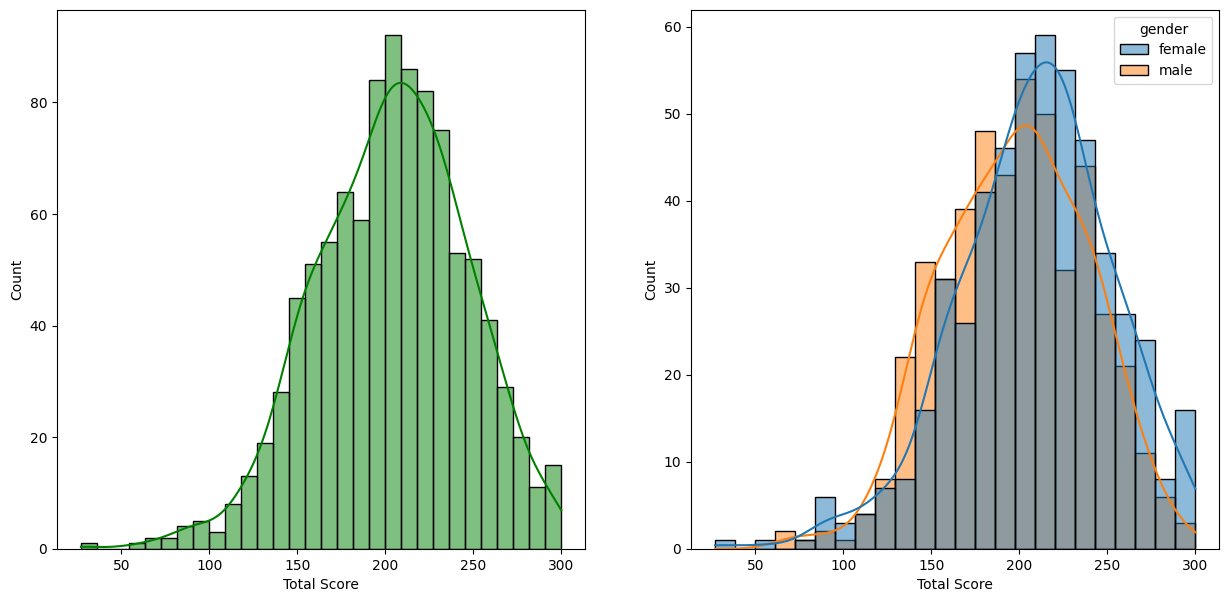

In [16]:
fig,axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Total Score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x="Total Score",kde=True,hue='gender')
plt.show()